In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("BMI_prediction_dataset.csv")

print("Columns in dataset and entries")
print("----"*20)
print(df.info())
print("----"*20)

Columns in dataset and entries
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption             

In [ ]:

print("Top 5 rows of dataset")
print("----"*20)
df.head()


Top 5 rows of dataset
--------------------------------------------------------------------------------


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
print("Statistical Summary of dataset")
print("----"*20)
df.describe().round(2)


Statistical Summary of dataset
--------------------------------------------------------------------------------


,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.00,8763.00,8763.00,8763.00,8763.00,8763.0,8763.0,8763.00,8763.00,8763.0,8763.0,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00
mean,53.71,259.88,75.02,0.65,0.49,0.9,0.5,0.60,10.01,0.5,0.5,5.47,5.99,158263.18,28.89,417.68,3.49,7.02,0.36
std,21.25,80.86,20.55,0.48,0.50,0.3,0.5,0.49,5.78,0.5,0.5,2.86,3.47,80575.19,6.32,223.75,2.28,1.99,0.48
min,18.00,120.00,40.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,1.00,0.00,20062.00,18.00,30.00,0.00,4.00,0.00
25%,35.00,192.00,57.00,0.00,0.00,1.0,0.0,0.00,4.98,0.0,0.0,3.00,3.00,88310.00,23.42,225.50,2.00,5.00,0.00
50%,54.00,259.00,75.00,1.00,0.00,1.0,1.0,1.00,10.07,0.0,0.0,5.00,5.93,157866.00,28.77,417.00,3.00,7.00,0.00
75%,72.00,330.00,93.00,1.00,1.00,1.0,1.0,1.00,15.05,1.0,1.0,8.00,9.02,227749.00,34.32,612.00,5.00,9.00,1.00
max,90.00,400.00,110.00,1.00,1.00,1.0,1.0,1.00,20.00,1.0,1.0,10.00,12.00,299954.00,40.00,800.00,7.00,10.00,1.00


In [ ]:
'''
Handeling missing values
'''
print("The number of null values in the features")
print(df.isna().sum())
print("----"*20)
'''
Droping the null value as they are very low so wont affect the outcome
and droping duplicates too
'''
df = df.dropna()
df = df.drop_duplicates()

The number of null values in the features
Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                

In [ ]:
'''
Splitting Blood pressure to Systolic and Dystolic blood pressure from object datatype to int"
'''
# Splitting Blood Pressure into two numeric columns
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df=df.drop('Blood Pressure', axis=1)

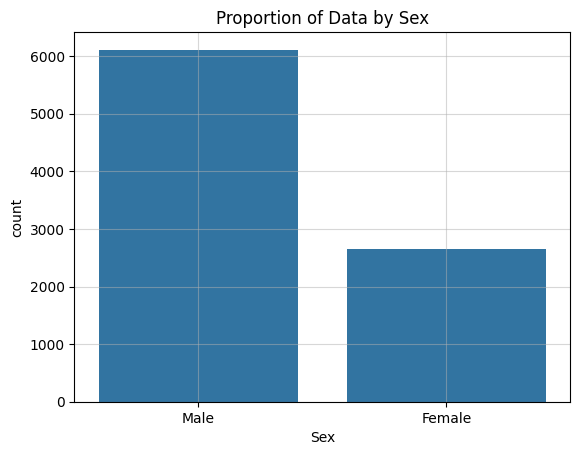

In [ ]:
'''
Visualizing Male and female proportion of data
'''
plt.title("Proportion of Data by Sex")
sns.countplot(x='Sex',data=df)
plt.grid(alpha=0.5)
plt.show()

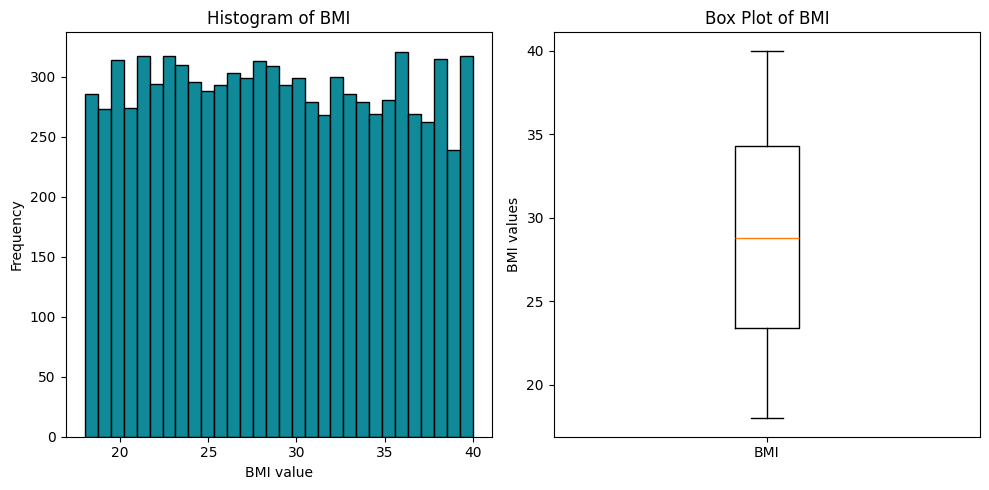

In [ ]:
'''
Visualizing BMI distribution
'''
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.set_title("Histogram of BMI")
ax1.hist(df['BMI'],bins=30, color='#108A99', edgecolor='black')
ax1.set_xlabel("BMI value")
ax1.set_ylabel("Frequency")

ax2.set_title("Box Plot of BMI")
ax2.boxplot(df['BMI'],tick_labels=['BMI'])
ax2.set_ylabel("BMI values")

plt.tight_layout()
plt.show()

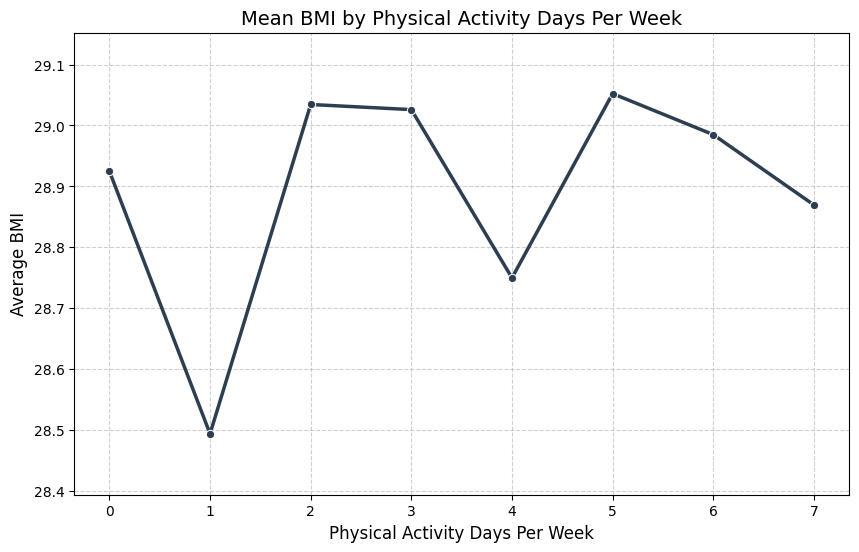

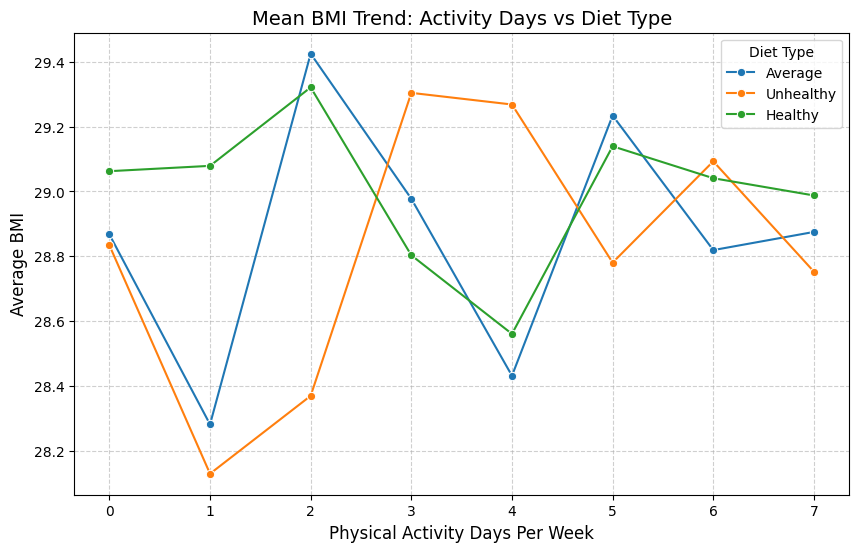

In [ ]:

# --- 1. Line Chart: Overall Mean BMI per Activity Day ---
# We group by the activity days and calculate the mean of BMI
mean_bmi_by_activity = df.groupby('Physical Activity Days Per Week')['BMI'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=mean_bmi_by_activity, x='Physical Activity Days Per Week',
             y='BMI', marker='o', linewidth=2.5, color='#2c3e50')

plt.title('Mean BMI by Physical Activity Days Per Week', fontsize=14)
plt.xlabel('Physical Activity Days Per Week', fontsize=12)
plt.ylabel('Average BMI', fontsize=12)

# Zooming in on the Y-axis helps visualize the small differences
plt.ylim(mean_bmi_by_activity['BMI'].min() - 0.1, mean_bmi_by_activity['BMI'].max() + 0.1)
plt.grid(True, linestyle='--', alpha=0.6)


# --- 2. Line Chart: Mean BMI split by Diet ---
# This helps see if activity affects BMI differently depending on what people eat
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Physical Activity Days Per Week', y='BMI',
             hue='Diet', marker='o', errorbar=None)

plt.title('Mean BMI Trend: Activity Days vs Diet Type', fontsize=14)
plt.xlabel('Physical Activity Days Per Week', fontsize=12)
plt.ylabel('Average BMI', fontsize=12)
plt.legend(title='Diet Type')
plt.grid(True, linestyle='--', alpha=0.6)


In [ ]:
'''
filtering columns removing unwanted columns
'''
df.info()

columns = df.columns
object_columns = list()
for i in columns:
  if(df[i].dtype=="object"):
    object_columns.append(i)

#using one hot encoding to change Diet column

diet_dummies = pd.get_dummies(df['Diet'],prefix="Diet",dtype=int)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null   object 
 12  Previous Heart Probl

In [ ]:
#Concating the 2 dataframes into the main

df=pd.concat([df,diet_dummies],axis=1)

df.head()

,Patient ID,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Systolic,Diastolic,Diet_Average,Diet_Healthy,Diet_Unhealthy
0,BMW7812,67,Male,208,72,0,0,1,0,0,...,6,Argentina,South America,Southern Hemisphere,0,158,88,1,0,0
1,CZE1114,21,Male,389,98,1,1,1,1,1,...,7,Canada,North America,Northern Hemisphere,0,165,93,0,0,1
2,BNI9906,21,Female,324,72,1,0,0,0,0,...,4,France,Europe,Northern Hemisphere,0,174,99,0,1,0
3,JLN3497,84,Male,383,73,1,1,1,0,1,...,4,Canada,North America,Northern Hemisphere,0,163,100,1,0,0
4,GFO8847,66,Male,318,93,1,1,1,1,0,...,5,Thailand,Asia,Northern Hemisphere,0,91,88,0,0,1


In [ ]:
#removing the unwanted Object columns
print(object_columns)

df=df.drop(columns=object_columns)


['Patient ID', 'Sex', 'Diet', 'Country', 'Continent', 'Hemisphere']


In [ ]:
df.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic,Diastolic,Diet_Average,Diet_Healthy,Diet_Unhealthy
0,67,208,72,0,0,1,0,0,4.168189,0,...,31.251233,286,0,6,0,158,88,1,0,0
1,21,389,98,1,1,1,1,1,1.813242,1,...,27.194973,235,1,7,0,165,93,0,0,1
2,21,324,72,1,0,0,0,0,2.078353,1,...,28.176571,587,4,4,0,174,99,0,1,0
3,84,383,73,1,1,1,0,1,9.828130,1,...,36.464704,378,3,4,0,163,100,1,0,0
4,66,318,93,1,1,1,1,0,5.804299,1,...,21.809144,231,1,5,0,91,88,0,0,1


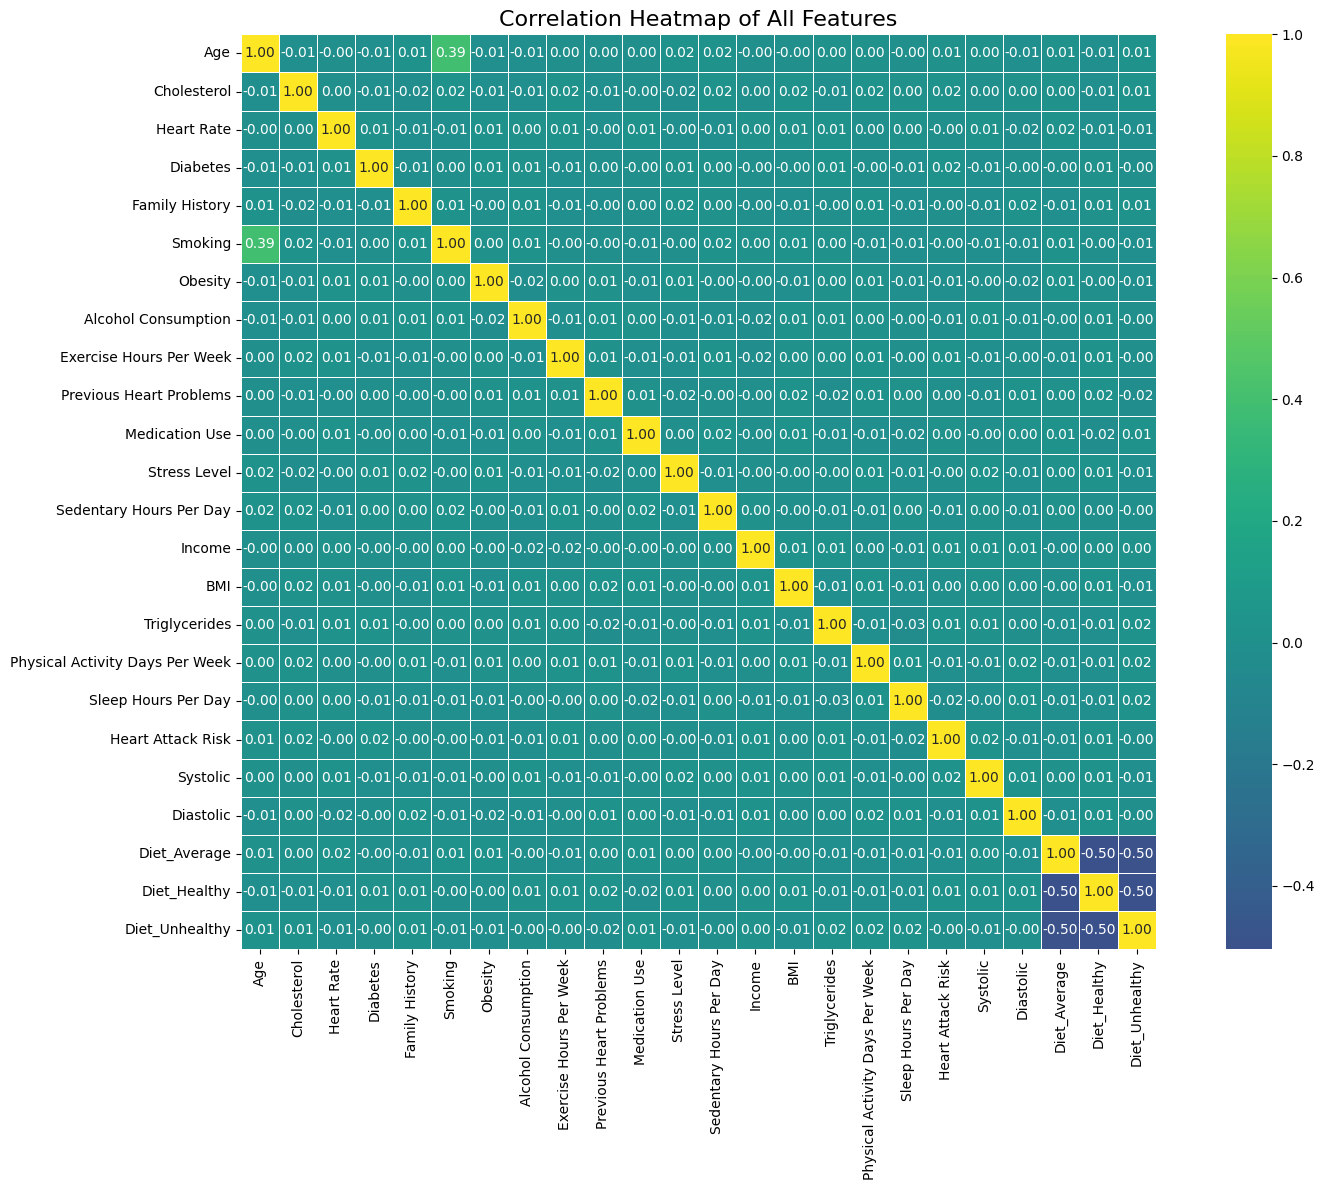

In [ ]:
#Correlation HeatMap to see the strenght of relations

plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.show()

# **Build a Neural Network Model for Regression**

In [ ]:
# Prepare features and target
X = df.drop('BMI', axis=1)
y = df['BMI']
feature_names = np.array(X.columns)

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature names: {feature_names}')

Features shape: (8763, 23)
Target shape: (8763,)
Feature names: ['Age' 'Cholesterol' 'Heart Rate' 'Diabetes' 'Family History' 'Smoking'
 'Obesity' 'Alcohol Consumption' 'Exercise Hours Per Week'
 'Previous Heart Problems' 'Medication Use' 'Stress Level'
 'Sedentary Hours Per Day' 'Income' 'Triglycerides'
 'Physical Activity Days Per Week' 'Sleep Hours Per Day'
 'Heart Attack Risk' 'Systolic' 'Diastolic' 'Diet_Average' 'Diet_Healthy'
 'Diet_Unhealthy']


In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SequentialFeatureSelector,SelectFromModel

In [ ]:
# Spliting dataset into training and testing

X_train,X_test,y_train,y_test = train_test_split(
    X,y,random_state=42,test_size=0.2,shuffle=True
)
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 7010
Testing set size: 1753


In [ ]:
# Scaling features for Neural Network

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Create and train MLP regressor
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),      # Slightly leaner
    activation='relu',               # ReLU is usually fine if lr is low
    solver='adam',
    alpha=0.01,                      # Increased regularization
    learning_rate_init=0.0005,       # Slower starting pace
    max_iter=1000,                   # Give it more time to converge
    early_stopping=True,
    validation_fraction=0.1,         # Hold out 10% for internal check
    n_iter_no_change=20,             # Be more patient before stopping
    random_state=42
)
print("\n🚀 Training MLP Regressor...")
mlp_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp_reg.predict(X_test_scaled)



🚀 Training MLP Regressor...


In [ ]:
# Evaluation metrics
print("\nRegression Performance:")
print("="*50)
print(f"Train R2 score: {r2_score(y_train,mlp_reg.predict(X_train_scaled))}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


Regression Performance:
Train R2 score: 0.03185956795406608
R² Score: -0.0805
Mean Absolute Error: 5.68
Mean Squared Error: 43.94
Root Mean Squared Error: 6.63


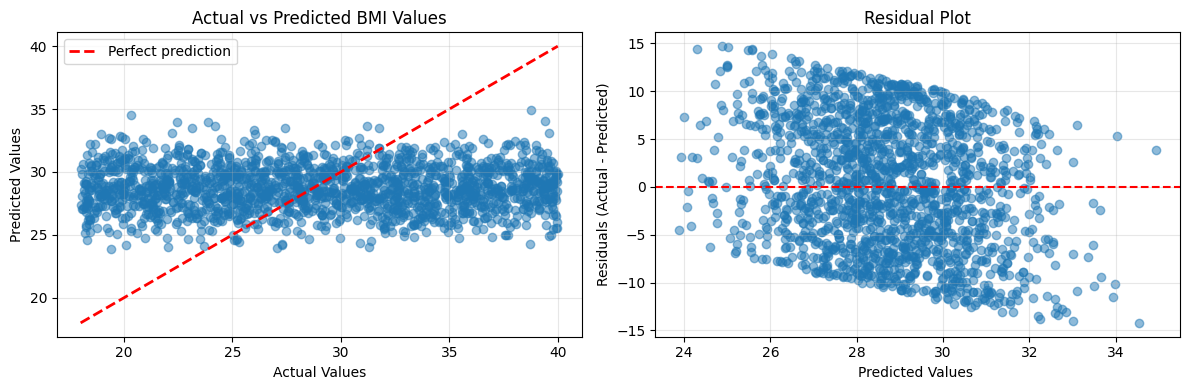

In [ ]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs Predicted
ax1.scatter(y_test, y_pred, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Actual vs Predicted BMI Values')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values ')
ax2.set_ylabel('Residuals (Actual - Predicted)')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

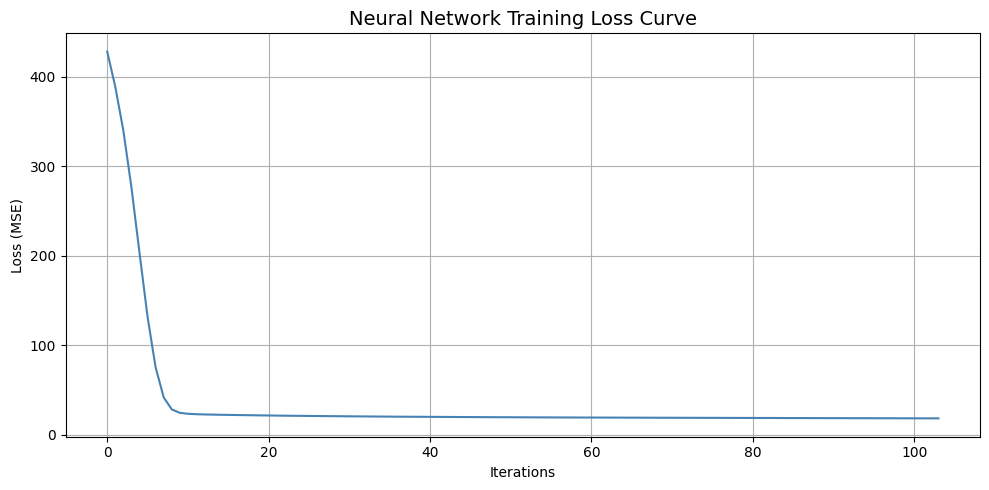

In [ ]:
# Plot training loss curve
if hasattr(mlp_reg, 'loss_curve_'):
  plt.figure(figsize=(10, 5))
  plt.plot(mlp_reg.loss_curve_, color='steelblue')
  plt.title('Neural Network Training Loss Curve', fontsize=14)
  plt.xlabel('Iterations')
  plt.ylabel('Loss (MSE)')
  plt.grid()
  plt.tight_layout()
  plt.show()

In [ ]:
'''
Linear Regression Model
'''

linear_model = LinearRegression();

linear_model.fit(X_train_scaled,y_train)

#Training and testing RMSE of linear model

linear_train_pred =linear_model.predict(X_train_scaled)
linear_test_pred =linear_model.predict(X_test_scaled)

linear_train_rmse = np.sqrt(mean_squared_error(y_train,linear_train_pred))
linear_test_rmse = np.sqrt(mean_squared_error(y_test,linear_test_pred))

print(f"Training RMSE of {linear_train_rmse:.3f}")
print(f"Testing RMSE of {linear_test_rmse:.3f}")

Training RMSE of 6.293
Testing RMSE of 6.415


In [ ]:
'''
Random Forest Regressior
'''
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

forest_model.fit(X_train_scaled,y_train)

#training and testing RMSE of Random Forest model

forest_train_pred = forest_model.predict(X_train_scaled)
forest_test_pred = forest_model.predict(X_test_scaled)

forest_train_rmse = np.sqrt(mean_squared_error(y_train,forest_train_pred))
forest_test_rmse = np.sqrt(mean_squared_error(y_test,forest_test_pred))

print(f"Training RMSE of {forest_train_rmse:.3f}")
print(f"Testing RMSE of {forest_test_rmse:.3f}")

Training RMSE of 2.394
Testing RMSE of 6.462


In [ ]:
# Initial comparison table
initial_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, linear_train_pred)),
        np.sqrt(mean_squared_error(y_train, forest_train_pred))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_test_pred)),
        np.sqrt(mean_squared_error(y_test, forest_test_pred))
    ],
    'Train R-squared': [
        r2_score(y_train, linear_train_pred),
        r2_score(y_train, forest_train_pred)
    ],
    'Test R-squared': [
        r2_score(y_test, linear_test_pred),
        r2_score(y_test, forest_test_pred)
    ]
})

print('Initial Model Comparison:')
print(initial_comparison.to_string(index=False))

Initial Model Comparison:
                  Model  Train RMSE  Test RMSE  Train R-squared  Test R-squared
      Linear Regression    6.293314   6.414828         0.003325       -0.011809
Random Forest Regressor    2.394020   6.462134         0.855772       -0.026787


In [ ]:
'''
Hyperparameter tuning for linear Regression model
'''
from sklearn.linear_model import Ridge

# Define parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
}

ridge_model = Ridge()

# GridSearchCV for Ridge Regression
grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search_ridge.fit(X_train, y_train)

print('=== Ridge Regression (Linear) - Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search_ridge.best_params_}')
print(f'Best CV R-squared Score: {grid_search_ridge.best_score_:.4f}')

=== Ridge Regression (Linear) - Hyperparameter Tuning ===
Best Parameters: {'alpha': 100.0}
Best CV R-squared Score: -0.0034


In [ ]:
'''
Hyperparameter tuning for Random Forest model
'''
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random_model = RandomForestRegressor(random_state=42)

# GridSearchCV for Random Forest
random_search_rf = RandomizedSearchCV(
    estimator=rf_random_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print('=== Random Forest Regressor - Hyperparameter Tuning ===')
print(f'Best Parameters: {random_search_rf.best_params_}')
print(f'Best CV R-squared Score: {random_search_rf.best_score_:.4f}')

=== Random Forest Regressor - Hyperparameter Tuning ===
Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
Best CV R-squared Score: -0.0056


In [ ]:
#making best model from hyperparameter tuning
best_linear = Ridge(alpha=100)
best_forest = RandomForestRegressor(max_depth=5,min_samples_leaf=2,min_samples_split=2,n_estimators=150)

#Selecting strategy for feature selection
linear_sfs_selector = SequentialFeatureSelector(estimator=best_linear, n_features_to_select=12,direction='forward')

forest_selector = SelectFromModel(best_forest, max_features=10, threshold=-np.inf)

#Training on train dataset
linear_sfs_selector.fit(X_train_scaled,y_train)
forest_selector.fit(X_train_scaled,y_train)

SelectFromModel(estimator=RandomForestRegressor(max_depth=5, min_samples_leaf=2,
                                                n_estimators=150),
                max_features=10, threshold=-inf)

In [ ]:
#Selected features indices
linear_selected_indices = linear_sfs_selector.get_support(indices=True)
forest_selected_indices = forest_selector.get_support(indices=True)

#Subsetting dataset with selected features

linear_X_train_selected = X_train_scaled[:,linear_selected_indices]
linear_X_test_selected = X_test_scaled[:,linear_selected_indices]

forest_X_train_selected = X_train_scaled[:,forest_selected_indices]
forest_X_test_selected = X_test_scaled[:,forest_selected_indices]

In [ ]:
#Selected features only
linear_selected_feature=feature_names[linear_selected_indices]
forest_selected_feature=feature_names[forest_selected_indices]

print("Selected feautre for linear Model: ")
print("----"*20)
print(linear_selected_feature)

print("----"*20)
print("Selected feature for Random Forest Model: ")
print(forest_selected_feature)

Selected feautre for linear Model: 
--------------------------------------------------------------------------------
['Cholesterol' 'Family History' 'Smoking' 'Obesity' 'Alcohol Consumption'
 'Previous Heart Problems' 'Income' 'Triglycerides'
 'Physical Activity Days Per Week' 'Sleep Hours Per Day' 'Systolic'
 'Diet_Average']
--------------------------------------------------------------------------------
Selected feature for Random Forest Model: 
['Age' 'Cholesterol' 'Heart Rate' 'Exercise Hours Per Week' 'Stress Level'
 'Sedentary Hours Per Day' 'Income' 'Triglycerides' 'Systolic' 'Diastolic']


In [ ]:
'''
final training and testing models with best hyperparameter and selected features
'''
final_linear = Ridge(alpha=100)
final_forest = RandomForestRegressor(max_depth=5,min_samples_leaf=2,min_samples_split=2,n_estimators=150)

final_linear.fit(linear_X_train_selected,y_train)
final_forest.fit(forest_X_train_selected,y_train)


final_test_linear_pred = final_linear.predict(linear_X_test_selected)
final_test_forest_pred = final_forest.predict(forest_X_test_selected)

cv_scores_linear = cross_val_score(final_linear, linear_X_train_selected, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_scores_forest = cross_val_score(final_forest, forest_X_train_selected, y_train, cv=5, scoring='neg_root_mean_squared_error')


In [ ]:
#Final comparison

final_comparison = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest Regressor'],
    'Features Used': ['12','10'],
    'CV Score (RMSE)': [cv_scores_linear.mean(), cv_scores_forest.mean()],
    'MSE' :[
        mean_squared_error(y_test, final_test_linear_pred),
        mean_squared_error(y_test, final_test_forest_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, final_test_linear_pred)),
        np.sqrt(mean_squared_error(y_test, final_test_forest_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test,final_test_linear_pred),
        mean_absolute_error(y_test,final_test_forest_pred)
    ],
    'R-squared': [
        r2_score(y_test, final_test_linear_pred),
        r2_score(y_test, final_test_forest_pred)
    ]
})

print('Final Model Comparison:')
print(final_comparison.to_string(index=False))


Final Model Comparison:
                  Model Features Used  CV Score (RMSE)       MSE     RMSE      MAE  R-squared
       Ridge Regression            12        -6.305040 41.070549 6.408631 5.541796  -0.009855
Random Forest Regressor            10        -6.314742 40.780787 6.385984 5.522315  -0.002730
